CREACIÓN DE MÁSCARAS

In [1]:
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from datetime import datetime
import pydicom
from pathlib import Path
import matplotlib.pyplot as plt
import os
import napari
import numpy as np
import cv2
import SimpleITK as sitk
import json

In [ ]:
class Phantom2D:
    def __init__(self):
        self.centro = np.array([0.0, 0.0])

        self.radio_exterior = 115.0
        self.radio_insertos = 55.7

        diametros = [37, 10, 13, 17, 22, 28]

        self.contorno = Circle(self.centro, self.radio_exterior)
        self.insertos = []

        n = len(diametros)
        for i, d in enumerate(diametros):
            ang = np.deg2rad(i * 360 / n)
            pos = [
                self.radio_insertos * np.cos(ang),
                self.radio_insertos * np.sin(ang)
            ]
            self.insertos.append(Circle(pos, d / 2))

    #def transformar(self, angulo_rad, dx, dy):
        #R = rotacion_2d(angulo_rad)
        #t = np.array([dx, dy])

        #self.contorno.transformar(R, t)
        #for c in self.insertos:
        #    c.transformar(R, t)



class Circle:
    def __init__(self, centro, radio):
        self.centro = np.array(centro, dtype=float)
        self.radio = radio

    #def transformar(self, R, t):
        #self.centro = R @ self.centro + t



#def rotacion_2d(theta):
    #c, s = np.cos(theta), np.sin(theta)
    #return np.array([
    #    [ c, -s],
    #    [ s,  c]
    #])

def dibujar_phantom(phantom, ax, color_contorno="black"):
    # Contorno exterior
    ax.add_patch(
        plt.Circle(
            phantom.contorno.centro,
            phantom.contorno.radio,
            fill=False,
            linewidth=2,
            color=color_contorno
        )
    )

    # Insertos
    for i, c in enumerate(phantom.insertos):
        ax.add_patch(
            plt.Circle(
                c.centro,
                c.radio,
                fill=False,
                linewidth=2
            )
        )



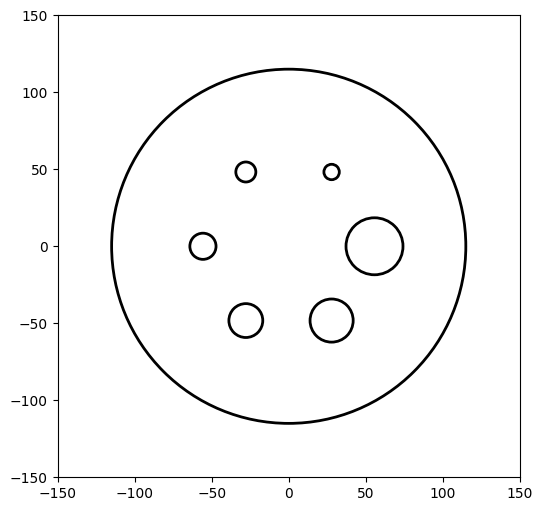

In [15]:
phantom = Phantom2D()

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")

dibujar_phantom(phantom, ax)

ax.set_xlim(-150, 150)
ax.set_ylim(-150, 150)
ax.grid(False)

plt.show()

In [2]:
class Phantom2D:
    def __init__(self): # Se ejecuta al crear la instancia de Phantom2D
        self.centro = np.array([0.0, 0.0]) # Define el centro del phantom en el origen de coordenadas

        self.radio_exterior = 115.0 # Radio del circulo exterior
        self.radio_insertos = 55.7  # Distancia desde el centro del phantom hasta el centro de cada esfera

        diametros = [37, 10, 13, 17, 22, 28]

        self.contorno = Circle(self.centro, self.radio_exterior) # Crea el círculo exterior usando la clase Circle
        self.insertos = []

        n = len(diametros) # Numero total de esferas
        for i, d in enumerate(diametros):
            ang = np.deg2rad(i * 360 / n) # Calcula el angulo para distribuir las esferas
            pos = [
                self.radio_insertos * np.cos(ang),
                self.radio_insertos * np.sin(ang)
            ] # Calcula la posicion de cada esfera
            self.insertos.append(Circle(pos, d / 2)) # Crea un circulo para cada esfera y la inserta



class Circle: # Clase genérica para representar un círculo
    def __init__(self, centro, radio):
        self.centro = np.array(centro, dtype=float)
        self.radio = radio

def phantom_a_imagen(phantom, shape):
    """
    shape: (alto, ancho) de la imagen 2D
    Función que convierte un objeto en una imagen 2D
    """
    img = np.zeros(shape, dtype=np.uint8)  # fondo negro. Imagen inicial llena de ceros (negro)
    alto, ancho = shape

    # Centrar phantom en la imagen
    desplazamiento = np.array([ancho/2, alto/2]) - phantom.centro
    # Calcula el vector de desplazamiento necesario para centrar el phantom en la imagen.
    insertos_viz = [ins.centro + desplazamiento for ins in phantom.insertos] 
    # Calcula los centros de los insertos ya desplazados al sistema de coordenadas de la imagen.

    yy, xx = np.meshgrid(np.arange(alto), np.arange(ancho), indexing='ij')
    # Genera dos matrices con las coordenadas (y, x) de cada píxel de la imagen.

    # Insertos
    for i, ins in enumerate(phantom.insertos):
        dist = np.sqrt((xx - insertos_viz[i][0])**2 + (yy - insertos_viz[i][1])**2)
        # Calcula la distancia de cada pixel al centro de la esfera i
        img[dist <= ins.radio] = 255  # Asigna el color blanco a los pixeles que están dentro del radio de la esfera

    return img



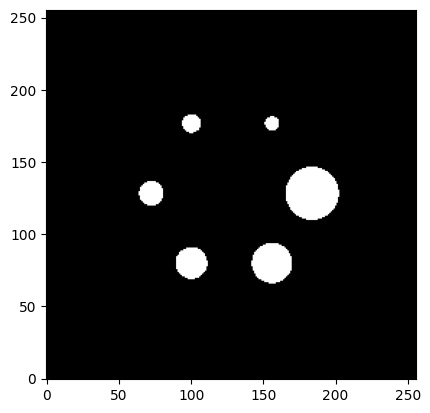

In [3]:
phantom = Phantom2D()
img_phantom = phantom_a_imagen(phantom, shape=(256,256))
plt.imshow(img_phantom, cmap='gray', origin='lower')
plt.show()